AI generated data file used for anomaly analysis of raptor hot-fire test.

```
============================================================
RAPTOR ENGINE SENSOR DATA - ANOMALY DETECTION PRACTICE
============================================================
Context:
    You are a software engineer on the Raptor Systems Modeling team.
    A hot-fire test was conducted on Raptor engine #R3-047.
    The test ran for 120 seconds at nominal throttle.
    
    You have been given a CSV of sensor readings sampled at 10 Hz.
    Something went wrong during the test. Your job is to find it.

Sensors recorded:
    - time_s          : time in seconds
    - chamber_pressure_bar : main combustion chamber pressure (bar)
    - fuel_flow_kgs   : fuel (methane) mass flow rate (kg/s)
    - ox_flow_kgs     : oxidizer (LOX) mass flow rate (kg/s)
    - turbine_temp_K  : fuel turbopump turbine inlet temperature (K)
    - thrust_kN       : measured thrust (kN)

Nominal operating conditions:
    - Chamber pressure: 350 bar ± 5 bar
    - Mixture ratio (ox/fuel): 3.6 ± 0.1
    - Turbine temp: 720 K ± 20 K
    - Thrust: 2100 kN ± 50 kN
```

In [ ]:
YOUR TASKS:
============================================================

TASK 1 — Load and inspect the data
    a) Load raptor_hotfire_R3047.csv into a pandas DataFrame
    b) Print shape, dtypes, and first 5 rows
    c) Check for any missing values

TASK 2 — Basic statistics
    a) Compute mean, std, min, max for all sensor channels
    b) Flag any channel whose mean falls outside nominal range
    c) Compute the mixture ratio (ox_flow / fuel_flow) over time
       and report its mean and std

TASK 3 — Time series visualization
    a) Plot all 5 sensor channels vs time on subplots
    b) Add horizontal lines showing nominal ± tolerance bands
    c) Visually identify the time window where anomaly occurs

TASK 4 — Anomaly detection
    a) Use a rolling window (window=50 samples = 5 seconds) to compute
       rolling mean and rolling std for chamber_pressure_bar
    b) Flag samples where the value deviates more than 3 sigma
       from the rolling mean
    c) Report: at what time does the anomaly start?
               how long does it last?
               what is the peak deviation?

TASK 5 — Root cause analysis
    a) During the anomaly window identified in Task 4:
       - Which OTHER sensors also show anomalous behavior?
       - Does mixture ratio change during this window?
       - Does turbine temp spike or drop?
    b) Based on the pattern across sensors, what is your hypothesis
       for root cause? (hint: think about what would cause chamber
       pressure to drop while turbine temp rises)

TASK 6 — Report
    Write a short function:
    
    def anomaly_report(df) -> dict:
        returns a dictionary with keys:
        {
            'anomaly_start_s': float,
            'anomaly_end_s': float,
            'anomaly_duration_s': float,
            'peak_pressure_deviation_bar': float,
            'affected_sensors': list,
            'hypothesis': str
        }


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

```
TASK 1 — Load and inspect the data
    a) Load raptor_hotfire_R3047.csv into a pandas DataFrame
    b) Print shape, dtypes, and first 5 rows
    c) Check for any missing values
```

In [6]:
# Task 1
df = pd.read_csv('./raptor_hotfire_R3047.csv')
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing values:\n{df.isnull().sum()}")



Shape: (1200, 6)

Dtypes:
time_s                  float64
chamber_pressure_bar    float64
fuel_flow_kgs           float64
ox_flow_kgs             float64
turbine_temp_K          float64
thrust_kN               float64
dtype: object

First 5 rows:
   time_s  chamber_pressure_bar  fuel_flow_kgs  ox_flow_kgs  turbine_temp_K  \
0     0.0                350.60         78.038      280.223           717.5   
1     0.1                349.83         77.871      280.941           717.8   
2     0.2                350.78         78.037      280.363           726.1   
3     0.3                351.83         78.163      280.583           720.0   
4     0.4                349.72         78.015      282.139           722.3   

   thrust_kN  
0     2104.1  
1     2099.5  
2     2088.8  
3     2094.3  
4     2097.9  

Missing values:
time_s                  0
chamber_pressure_bar    0
fuel_flow_kgs           0
ox_flow_kgs             0
turbine_temp_K          1
thrust_kN               0
dtype: int64


In [ ]:
# Fill NaN with interpolation for time series
df['turbine_temp_K'] = df['turbine_temp_K'].interpolate()
print(f"\nMissing values:\n{df.isnull().sum()}")

# Interpolation (time series) rather than foward fill.
# because turbine temperature is a continuous physical quantity governed by thermal dynamics 
#   it can't jump discontinuously. 
# A single sensor dropout at 10Hz represents a 0.1 second gap, 
#   and linear interpolation between neighboring valid readings is physically realistic for that timescale. 


# Ideally the physics model itself would provide the imputed value


Missing values:
time_s                  0
chamber_pressure_bar    0
fuel_flow_kgs           0
ox_flow_kgs             0
turbine_temp_K          0
thrust_kN               0
dtype: int64


```
TASK 2 — Basic statistics
    a) Compute mean, std, min, max for all sensor channels
    b) Flag any channel whose mean falls outside nominal range
    c) Compute the mixture ratio (ox_flow / fuel_flow) over time
       and report its mean and std
```

In [31]:
df['mixture_ratio'] = np.where(df['fuel_flow_kgs']>0, df['ox_flow_kgs']/df['fuel_flow_kgs'], np.nan)
df.describe().round(2)


,time_s,chamber_pressure_bar,fuel_flow_kgs,ox_flow_kgs,turbine_temp_K,thrust_kN,mixture_ratio
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1199.00
mean,59.95,349.02,75.15,280.81,722.20,2093.12,4.06
std,34.66,3.56,9.34,0.82,8.22,22.64,3.97
min,0.00,320.70,0.00,278.41,710.50,1930.70,3.54
25%,29.98,348.65,77.67,280.23,718.30,2090.10,3.59
50%,59.95,349.79,77.94,280.81,720.70,2097.90,3.60
75%,89.93,350.68,78.17,281.35,723.20,2103.80,3.62
max,119.90,354.62,78.96,283.94,786.70,2124.90,85.19


In [27]:
df.skew()

time_s                 -2.243221e-16
chamber_pressure_bar   -4.218124e+00
fuel_flow_kgs          -5.009357e+00
ox_flow_kgs             1.679614e-02
turbine_temp_K          4.080613e+00
thrust_kN              -4.069451e+00
dtype: float64

Observations:
- Fuel flow drops to 0
- Chamber pressure drops below nominal value
- Thrust drops below nominal value
- Turbine temperature exceed nominal value and spikes by 67K

Skewness:
- chamber pressure tail pulls left (negative skew) = anomaly dip
- fuel flow shows very strong negative skew (due to zero min)
- turbine Temp: positive skew (temp spike)
- thrust: negative skew
- Ox flow: Almost zero (symmetric and unaffected)

Summary:
- Before even plotting anything, the statistics are already pointing toward a fuel valve or fuel line anomaly.


```
TASK 3 — Time series visualization
    a) Plot all 5 sensor channels vs time on subplots
    b) Add horizontal lines showing nominal ± tolerance bands
    c) Visually identify the time window where anomaly occurs
```

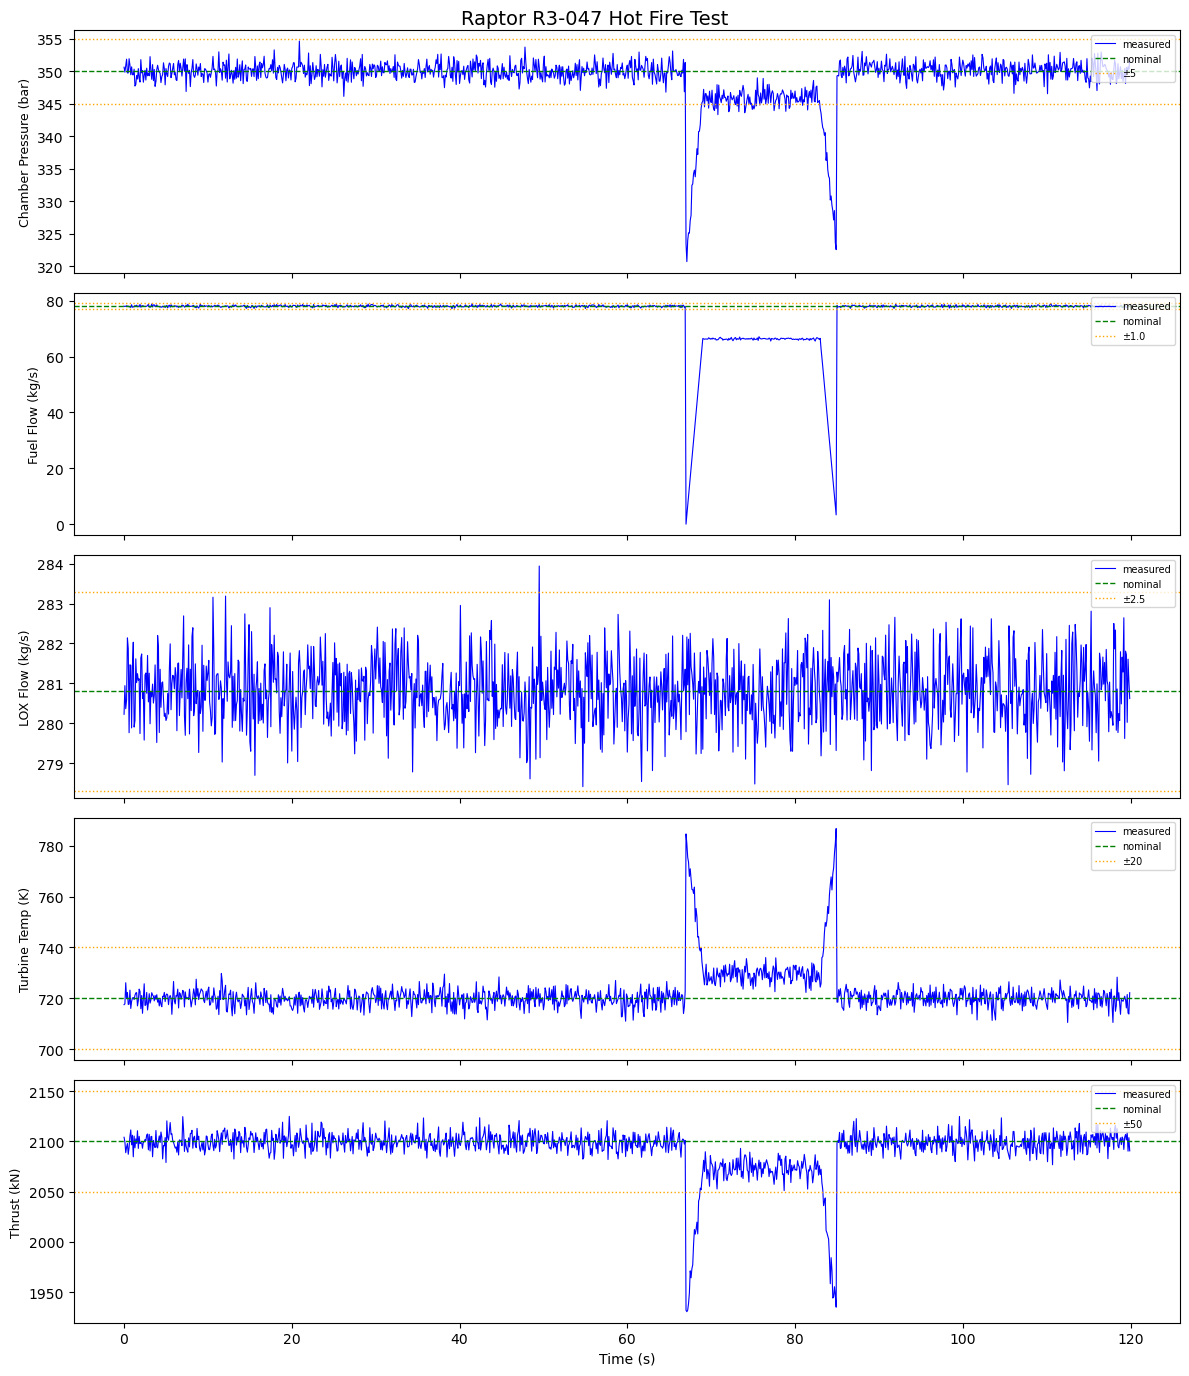

In [45]:
fig, axes = plt.subplots(5,1,figsize=(12,14), sharex=True)
fig.suptitle("Raptor R3-047 Hot Fire Test", fontsize=14)

sensors = [
        ('chamber_pressure_bar', 'Chamber Pressure (bar)', 350, 5),
        ('fuel_flow_kgs',        'Fuel Flow (kg/s)',       78.0, 1.0),
        ('ox_flow_kgs',          'LOX Flow (kg/s)',        280.8, 2.5),
        ('turbine_temp_K',       'Turbine Temp (K)',       720, 20),
        ('thrust_kN',            'Thrust (kN)',            2100, 50),
]

for ax, (col, label, nom, tol) in zip(axes,sensors):
    ax.plot(df['time_s'], df[col], 'b-', linewidth=0.8, label='measured')
    ax.axhline(nom,color='g', linestyle='--', linewidth=1, label='nominal')
    ax.axhline(nom + tol, color='orange', linestyle=':', linewidth=1, label=f'±{tol}')
    ax.axhline(nom - tol, color='orange', linestyle=':', linewidth=1)
    ax.set_ylabel(label, fontsize=9)
#     ax.set_xlabel('time_s', fontsize=9)
    ax.legend(loc='upper right', fontsize=7)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


Observation
- Anomaly window: 67-85 s
- Fuel flow drops to zero completely, then recovers not to fully nominal 78kg/s
- Two dips... looks like valve fully closing then only partially opening.
- LOX flow is unaffected
- Same spike patterns in other sensors due to fuel anomaly:
    - Turbine temperature rise to 780K (less fuel -> Ox rich preburner -> hotter)
    - Chamber pressure and thrust both drop at anomaly. Recovers partially and dip again. 
        (less combustion mass flow -> chamber pressure drop)




Conclusion:
- fuel side anomaly



In [51]:
nominal_window = df[df['time_s'] < 60]
anomaly_window = df[(df['time_s'] >= 67) & (df['time_s'] <= 85)]

print("Nominal vs Anomaly comparison:")
for col in ['chamber_pressure_bar', 'fuel_flow_kgs', 
            'ox_flow_kgs', 'turbine_temp_K', 'thrust_kN']:
    nom = nominal_window[col].mean()
    anom = anomaly_window[col].mean()
    delta = anom - nom
    pct = delta / nom * 100
    print(f"{col:30s}: Δ = {delta:+.2f} ({pct:+.1f}%)")

Nominal vs Anomaly comparison:
chamber_pressure_bar          : Δ = -6.76 (-1.9%)
fuel_flow_kgs                 : Δ = -18.98 (-24.3%)
ox_flow_kgs                   : Δ = -0.05 (-0.0%)
turbine_temp_K                : Δ = +15.50 (+2.2%)
thrust_kN                     : Δ = -43.36 (-2.1%)


In [55]:
df['pressure_rate'] = df['chamber_pressure_bar'].diff() / 0.1  # bar per second
print(f"{df['pressure_rate'].min()} bar per sec")  # fastest drop rate
print(f"{df['pressure_rate'].idxmin()} sec")  # when it happened

-278.1 bar per sec
670 sec


In [57]:
# First dip
event1 = df[(df['time_s'] >= 67) & (df['time_s'] <= 75)]
# Second dip  
event2 = df[(df['time_s'] >= 82) & (df['time_s'] <= 86)]

print(f"Event 1 min pressure: {event1['chamber_pressure_bar'].min():.1f} bar")
print(f"Event 2 min pressure: {event2['chamber_pressure_bar'].min():.1f} bar")
print(f"Event 1 min fuel flow: {event1['fuel_flow_kgs'].min():.1f} kg/s")
print(f"Event 2 min fuel flow: {event2['fuel_flow_kgs'].min():.1f} kg/s")

Event 1 min pressure: 320.7 bar
Event 2 min pressure: 322.6 bar
Event 1 min fuel flow: 0.0 kg/s
Event 2 min fuel flow: 3.3 kg/s


In [56]:
# Cross correlation between sensors

# Do fuel flow and chamber pressure move together?
correlation = df[['chamber_pressure_bar', 
                   'fuel_flow_kgs',
                   'turbine_temp_K',
                   'thrust_kN']].corr()
print(correlation.round(3))


                      chamber_pressure_bar  fuel_flow_kgs  turbine_temp_K  \
chamber_pressure_bar                 1.000          0.943          -0.876   
fuel_flow_kgs                        0.943          1.000          -0.932   
turbine_temp_K                      -0.876         -0.932           1.000   
thrust_kN                            0.878          0.934          -0.866   

                      thrust_kN  
chamber_pressure_bar      0.878  
fuel_flow_kgs             0.934  
turbine_temp_K           -0.866  
thrust_kN                 1.000  


```
TASK 4 — Anomaly detection
    a) Use a rolling window (window=50 samples = 5 seconds) to compute
       rolling mean and rolling std for chamber_pressure_bar
    b) Flag samples where the value deviates more than 3 sigma
       from the rolling mean
    c) Report: at what time does the anomaly start?
               how long does it last?
               what is the peak deviation?
```

In [67]:
# window = 50
# df['P_roll_mean']   = df['chamber_pressure_bar'].rolling(window, center=False).mean()
# df['P_roll_std']    = df['chamber_pressure_bar'].rolling(window, center=False).std()
# df['P_zscore']      = (df['chamber_pressure_bar'] - df['P_roll_mean']) / df['P_roll_std']

## Don't use rolling average for z_score. Compute z score from known good data only <60sec
baseline = df[df['time_s'] < 60]
baseline_mean = baseline['chamber_pressure_bar'].mean()
baseline_std = baseline['chamber_pressure_bar'].std()
df['P_zscore']      = (df['chamber_pressure_bar'] - baseline_mean) / baseline_std

anomaly_mask = (df['P_zscore'].abs() > 3.0) & (df['chamber_pressure_bar'] < 345)
anomaly_df = df[anomaly_mask]

In [68]:
if not anomaly_df.empty:
    t_start = anomaly_df['time_s'].min()
    t_end = anomaly_df['time_s'].max()
    duration = t_end - t_start
    peak_dev = (df.loc[anomaly_mask, 'chamber_pressure_bar'] -350).abs().max()
    print(f"Anomaly start:    {t_start:.1f} s")
    print(f"Anomaly end:      {t_end:.1f} s")
    print(f"Duration:         {duration:.1f} s")
    print(f"Peak deviation:   {peak_dev:.1f} bar from nominal")

Anomaly start:    67.0 s
Anomaly end:      84.9 s
Duration:         17.9 s
Peak deviation:   29.3 bar from nominal


```
TASK 5 — Root cause analysis
    a) During the anomaly window identified in Task 4:
       - Which OTHER sensors also show anomalous behavior?
       - Does mixture ratio change during this window?
       - Does turbine temp spike or drop?
    b) Based on the pattern across sensors, what is your hypothesis
       for root cause? (hint: think about what would cause chamber
       pressure to drop while turbine temp rises)
```

In [74]:
anom_window = df[(df['time_s'] >= t_start) & (df['time_s'] <= t_end)]
nominal_window = df[df['time_s'] < 60]

for col in ['chamber_pressure_bar', 'fuel_flow_kgs', 'ox_flow_kgs', 'turbine_temp_K', 'thrust_kN', 'mixture_ratio']:
    nom_mean = nominal_window[col].mean()
    anom_mean = anomaly_window[col].mean()
    delta = anom_mean - nom_mean
    print(f"  {col:30s}: nominal={nom_mean:8.2f}  anomaly={anom_mean:8.2f}  Δ={delta:+.2f}")


  chamber_pressure_bar          : nominal=  349.98  anomaly=  343.22  Δ=-6.76
  fuel_flow_kgs                 : nominal=   78.02  anomaly=   59.04  Δ=-18.98
  ox_flow_kgs                   : nominal=  280.83  anomaly=  280.77  Δ=-0.05
  turbine_temp_K                : nominal=  719.83  anomaly=  735.32  Δ=+15.50
  thrust_kN                     : nominal= 2099.94  anomaly= 2056.59  Δ=-43.36
  mixture_ratio                 : nominal=    3.60  anomaly=    6.68  Δ=+3.08


```
TASK 6 — Report
    Write a short function:
    
    def anomaly_report(df) -> dict:
        returns a dictionary with keys:
        {
            'anomaly_start_s': float,
            'anomaly_end_s': float,
            'anomaly_duration_s': float,
            'peak_pressure_deviation_bar': float,
            'affected_sensors': list,
            'hypothesis': str
        }
```